Outliers and missing mass: unbalanced and semi-unbalanced OT
============================================================

**When to use:** one cloud has outliers, or parts the other cloud lacks, and balanced OT would force all of that
mass to be transported.

**What you will see:** on 30,000 points whose target has 5% outliers, where balanced OT sends the mass; how
``reach`` lets mass be destroyed or created instead; how relaxing only the target, the side with the outliers,
keeps the source constraint, so all source mass is still transported; and how much outlier mass is kept as
``reach`` grows. GeomLoss's documentation describes ``reach`` in the same terms:
https://www.kernel-operations.io/geomloss/api/pytorch-api.html

Source: [plot_unbalanced.py](plot_unbalanced.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/choosing_parameters/plot_unbalanced.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/choosing_parameters/plot_unbalanced.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (dense_size, fit_limits, images_dir, require_cuda, save, small_multiples, table,  # noqa: E402
                       timed, to_numpy)
from _transport import marginals  # noqa: E402

device = require_cuda()
torch.manual_seed(0)
n = m = 30_000
k = m // 20  # 5% of the target are outliers
x = 0.3 * torch.randn(n, 2, device=device)
y = 0.3 * torch.randn(m, 2, device=device) + torch.tensor([1.0, 0.0], device=device)
y[:k] = 0.1 * torch.randn(k, 2, device=device) + torch.tensor([1.0, 3.0], device=device)
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(n, m))
blur = 0.05


def transported(scaling=0.99, **relaxation):
    """Mass sent from each source point and received by each target point, relative to its weight."""
    loss = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                       scaling=scaling, allow_tf32=False, autotune=False, **relaxation)
    f, g = loss(a, x, b, y)
    row, col = marginals(x, y, f, g, a, b, eps=blur**2, cost_scale=0.5)
    return row / a, col / b

Three ways to treat the outliers
--------------------------------
Balanced OT must send all source mass and fill all target mass, the outliers included. ``reach=r`` replaces
both marginal constraints by a penalty of strength r^2: mass that would travel much farther than r is
destroyed at the source or created at the target instead. ``reach_x=None, reach_y=r`` relaxes only the target,
the side with the outliers, so all source mass is still transported. (The plans come from slow FP32 solves, as
in the basics example: points coloured by mass ratios magnify any marginal error.)

In [ ]:
settings = {"balanced": {}, "reach = 1, both sides": dict(reach=1.0),
            "reach_y = 1, target only": dict(reach_x=None, reach_y=1.0)}
ratios = {}
for name, relaxation in settings.items():
    ratios[name] = timed(name, lambda: transported(**relaxation))
    sent, received = ratios[name]
    print(f"  mass moved {(sent * a).sum().item():.3f}, outlier mass kept {received[:k].mean().item():.3f}, "
          f"worst |sent / a - 1| {(sent - 1).abs().max().item():.2e}")

# Top row: each source point coloured by the mass it sends; bottom row: each target point by the mass it
# receives, both relative to its weight. The other cloud is drawn in grey.
xs, ys = to_numpy(x), to_numpy(y)
fig, axes = small_multiples(2, 3, size=3.4, aspect=4.4 / 3.2)
for col, (name, (sent, received)) in enumerate(ratios.items()):
    for row, (points, other, ratio, side) in enumerate(((xs, ys, sent, "source: mass sent"),
                                                         (ys, xs, received, "target: mass received"))):
        ax = axes[row, col]
        ax.scatter(other[:, 0], other[:, 1], s=0.5, color="0.85", edgecolors="none", rasterized=True)
        image = ax.scatter(points[:, 0], points[:, 1], c=to_numpy(ratio), s=0.5, cmap="viridis", vmin=0, vmax=1.5,
                           edgecolors="none", rasterized=True)
        fit_limits(ax, x, y)
        ax.set_title(f"{name}\n{side}" if row == 0 else side, fontsize=10)
fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label="transported mass / weight")
save(fig, images_dir(__file__), "unbalanced")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/choosing_parameters/images/unbalanced.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

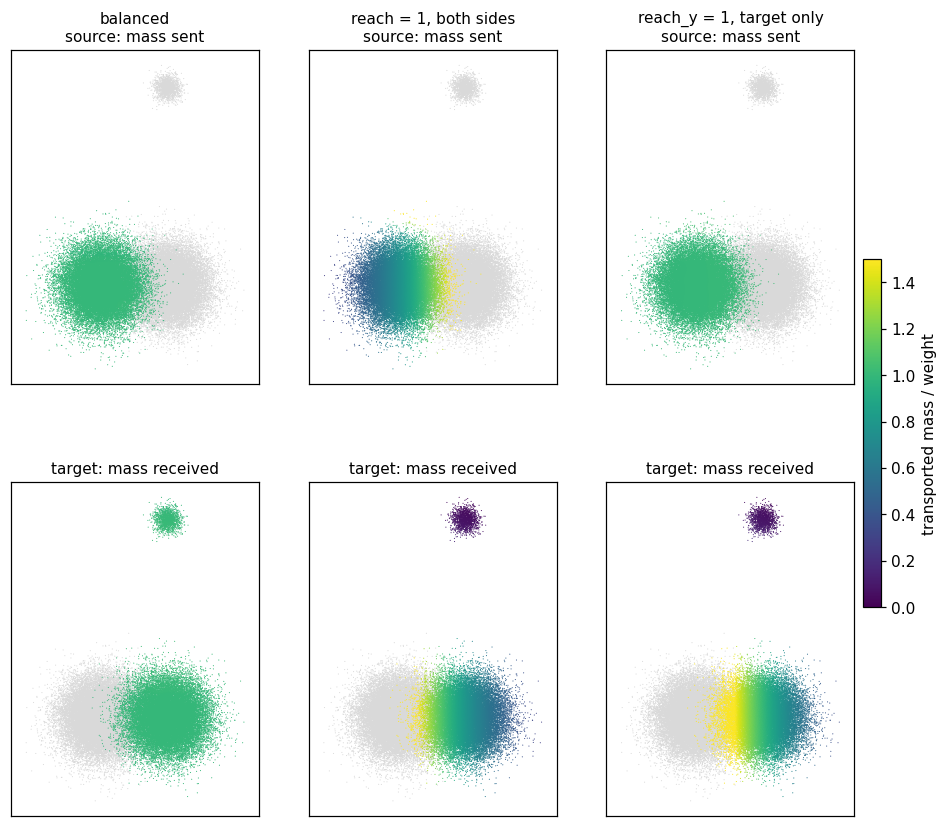

How much outlier mass is kept
-----------------------------
Relaxing the target only, outlier mass is kept once reach approaches the distance to the outliers. Relaxing
both sides with a reach shorter than the distances the bulk must travel destroys part of the bulk as well.
These totals need less accuracy than per-point ratios, so the sweep uses a faster schedule.

In [ ]:
reaches = [0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]
kept, moved = [], []
for r in reaches:
    received = transported(scaling=0.95, reach_x=None, reach_y=r)[1]
    sent = transported(scaling=0.95, reach=r)[0]
    kept.append(received[:k].mean().item())
    moved.append((sent * a).sum().item())
    print(f"reach {r:5.1f}: outlier mass kept (target only) {kept[-1]:.3f}, mass moved (both sides) {moved[-1]:.3f}")
fig, ax = plt.subplots(figsize=(6.0, 3.4))
table(ax, ["reach", "outlier mass kept (reach_y only)", "mass moved (reach, both sides)"],
      [[f"{r:g}", f"{kept_r:.3f}", f"{moved_r:.3f}"] for r, kept_r, moved_r in zip(reaches, kept, moved)])
save(fig, images_dir(__file__), "unbalanced_reach")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/choosing_parameters/images/unbalanced_reach.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

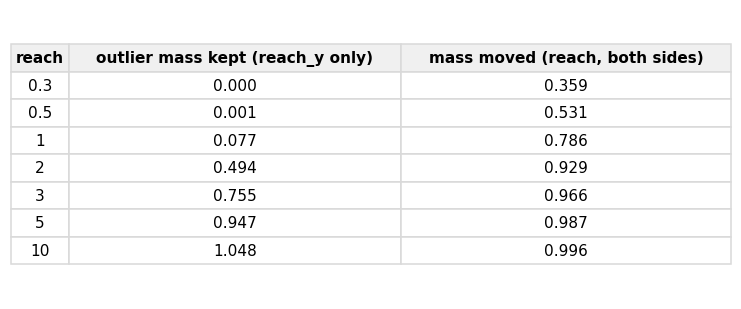